In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from scipy import stats

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

matches = pd.read_csv('../dataset/matches.csv')
deliveries = pd.read_csv('../dataset/deliveries.csv')

# Fix team names
team_name_map = {
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Delhi Capitals': 'Delhi Daredevils',
    'Punjab Kings': 'Kings XI Punjab',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
matches.replace(team_name_map, inplace=True)
deliveries.replace(team_name_map, inplace=True)

print("Data loaded successfully!")

Data loaded successfully!


In [17]:
matches['toss_won_match'] = (matches['toss_winner'] == matches['winner']).astype(int)
matches['toss_won'] = (matches['toss_winner'] == matches['team1']).astype(int)

toss_corr = matches['toss_won_match'].value_counts(normalize=True) * 100

corr_value, p_value = stats.pointbiserialr(
    matches['toss_won'],
    matches['toss_won_match']
)

print("=== TOSS WIN VS MATCH WIN CORRELATION ===")
print(f"Toss winner won the match: {toss_corr[1]:.1f}%")
print(f"Toss winner lost the match: {toss_corr[0]:.1f}%")
print(f"\nCorrelation coefficient: {corr_value:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"\nConclusion: {'Toss DOES significantly impact match outcome' if p_value < 0.05 else 'Toss does NOT significantly impact match outcome'}")

=== TOSS WIN VS MATCH WIN CORRELATION ===
Toss winner won the match: 50.6%
Toss winner lost the match: 49.4%

Correlation coefficient: 0.0224
P-value: 0.4589

Conclusion: Toss does NOT significantly impact match outcome


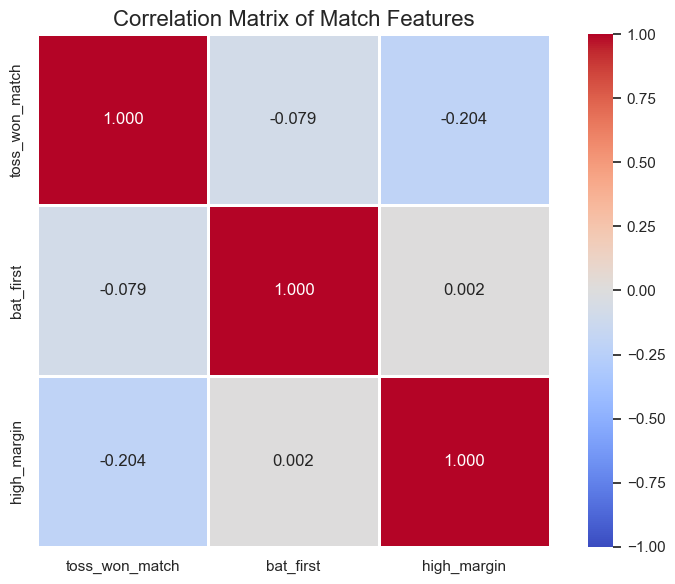

                toss_won_match  bat_first  high_margin
toss_won_match        1.000000  -0.079376    -0.204074
bat_first            -0.079376   1.000000     0.002044
high_margin          -0.204074   0.002044     1.000000


In [18]:
matches['toss_won_match'] = (matches['toss_winner'] == matches['winner']).astype(int)
matches['bat_first'] = (matches['toss_decision'] == 'bat').astype(int)
matches['high_margin'] = (matches['result_margin'] > matches['result_margin'].median()).astype(int)

corr_df = matches[['toss_won_match', 'bat_first', 'high_margin']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='coolwarm', 
            linewidths=1, square=True, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Match Features', fontsize=16)
plt.tight_layout()
plt.show()

print(corr_df)

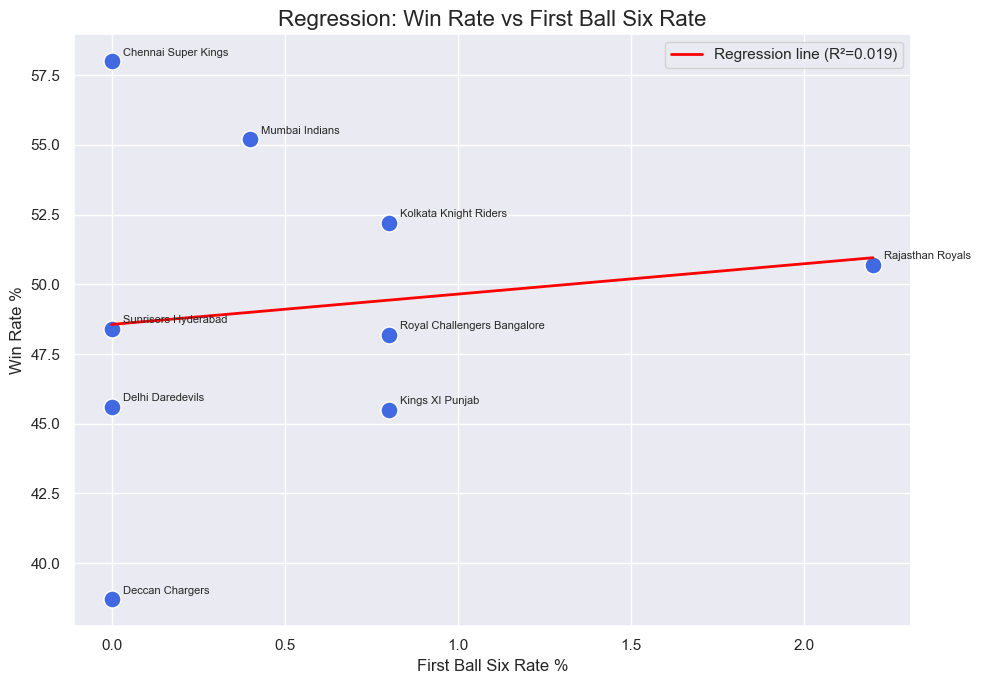

=== REGRESSION RESULTS ===
R² value: 0.0186
P-value: 0.7262
Slope: 1.0880
Conclusion: No significant relationship found


In [19]:
# Build team stats
all_teams = pd.concat([matches['team1'], matches['team2']]).unique()

team_stats = []
for team in all_teams:
    played = matches[(matches['team1'] == team) | (matches['team2'] == team)]
    won = matches[matches['winner'] == team]
    win_rate = len(won) / len(played) * 100 if len(played) > 0 else 0

    first_ball = deliveries[(deliveries['over'] == 0) & (deliveries['ball'] == 1) & 
                             (deliveries['batting_team'] == team)]
    first_ball_sixes = len(first_ball[first_ball['batsman_runs'] == 6])
    six_rate = first_ball_sixes / len(first_ball) * 100 if len(first_ball) > 0 else 0

    if len(played) >= 50:
        team_stats.append({'team': team, 'win_rate': round(win_rate, 1), 'six_rate': round(six_rate, 1)})

team_stats_df = pd.DataFrame(team_stats)

# Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    team_stats_df['six_rate'], team_stats_df['win_rate']
)

x = np.linspace(team_stats_df['six_rate'].min(), team_stats_df['six_rate'].max(), 100)
y = slope * x + intercept

plt.figure(figsize=(10, 7))
sns.scatterplot(data=team_stats_df, x='six_rate', y='win_rate', s=150, color='royalblue')

for _, row in team_stats_df.iterrows():
    plt.annotate(row['team'], (row['six_rate'], row['win_rate']),
                 textcoords='offset points', xytext=(8, 4), fontsize=8)

plt.plot(x, y, color='red', linewidth=2, label=f'Regression line (R²={r_value**2:.3f})')
plt.title('Regression: Win Rate vs First Ball Six Rate', fontsize=16)
plt.xlabel('First Ball Six Rate %')
plt.ylabel('Win Rate %')
plt.legend()
plt.tight_layout()
plt.show()

print("=== REGRESSION RESULTS ===")
print(f"R² value: {r_value**2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Slope: {slope:.4f}")
print(f"Conclusion: {'Significant relationship found' if p_value < 0.05 else 'No significant relationship found'}")

In [20]:
# Prepare features
le_team = LabelEncoder()
le_venue = LabelEncoder()

model_df = matches.dropna(subset=['winner']).copy()
model_df['team1_enc'] = le_team.fit_transform(model_df['team1'])
model_df['team2_enc'] = le_team.transform(model_df['team2'].map(
    lambda x: x if x in le_team.classes_ else le_team.classes_[0]))
model_df['venue_enc'] = le_venue.fit_transform(model_df['venue'])
model_df['toss_decision_enc'] = (model_df['toss_decision'] == 'bat').astype(int)
model_df['toss_winner_enc'] = (model_df['toss_winner'] == model_df['team1']).astype(int)
model_df['winner_enc'] = (model_df['winner'] == model_df['team1']).astype(int)

features = ['team1_enc', 'team2_enc', 'venue_enc', 'toss_decision_enc', 'toss_winner_enc']
X = model_df[features]
y = model_df['winner_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("=== MATCH WINNER PREDICTION MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

=== MATCH WINNER PREDICTION MODEL ===
Accuracy: 54.1%

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.54      0.54       110
           1       0.54      0.55      0.54       108

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



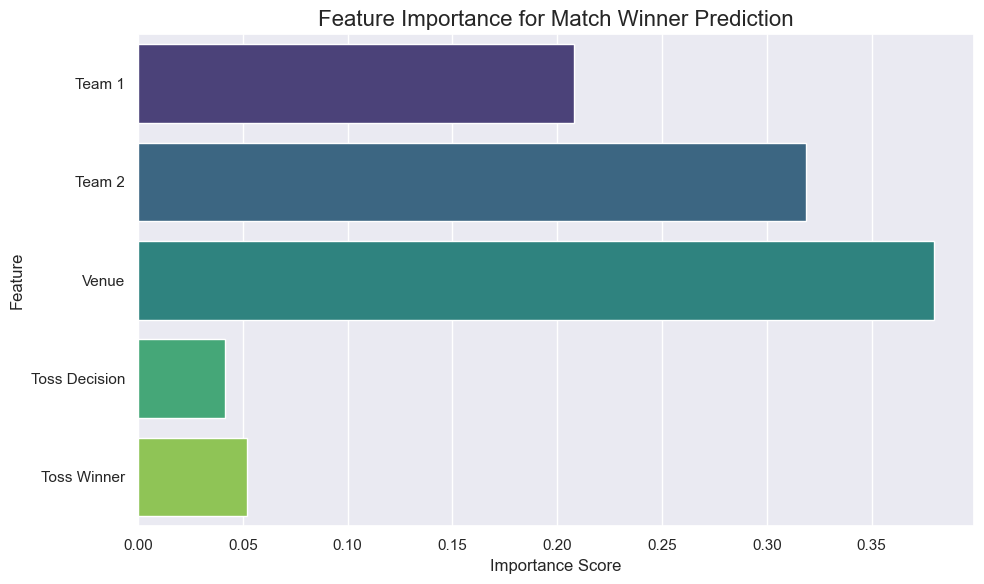


=== FEATURE IMPORTANCES ===
Team 1: 0.2080
Team 2: 0.3186
Venue: 0.3799
Toss Decision: 0.0415
Toss Winner: 0.0521


In [21]:
feature_names = ['Team 1', 'Team 2', 'Venue', 'Toss Decision', 'Toss Winner']
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names, hue=feature_names, palette='viridis', legend=False)
plt.title('Feature Importance for Match Winner Prediction', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\n=== FEATURE IMPORTANCES ===")
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")

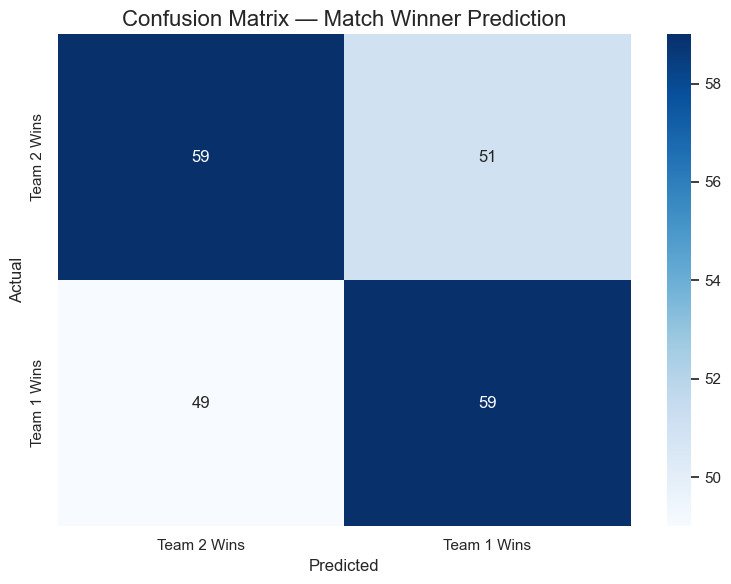

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team 2 Wins', 'Team 1 Wins'],
            yticklabels=['Team 2 Wins', 'Team 1 Wins'])
plt.title('Confusion Matrix — Match Winner Prediction', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

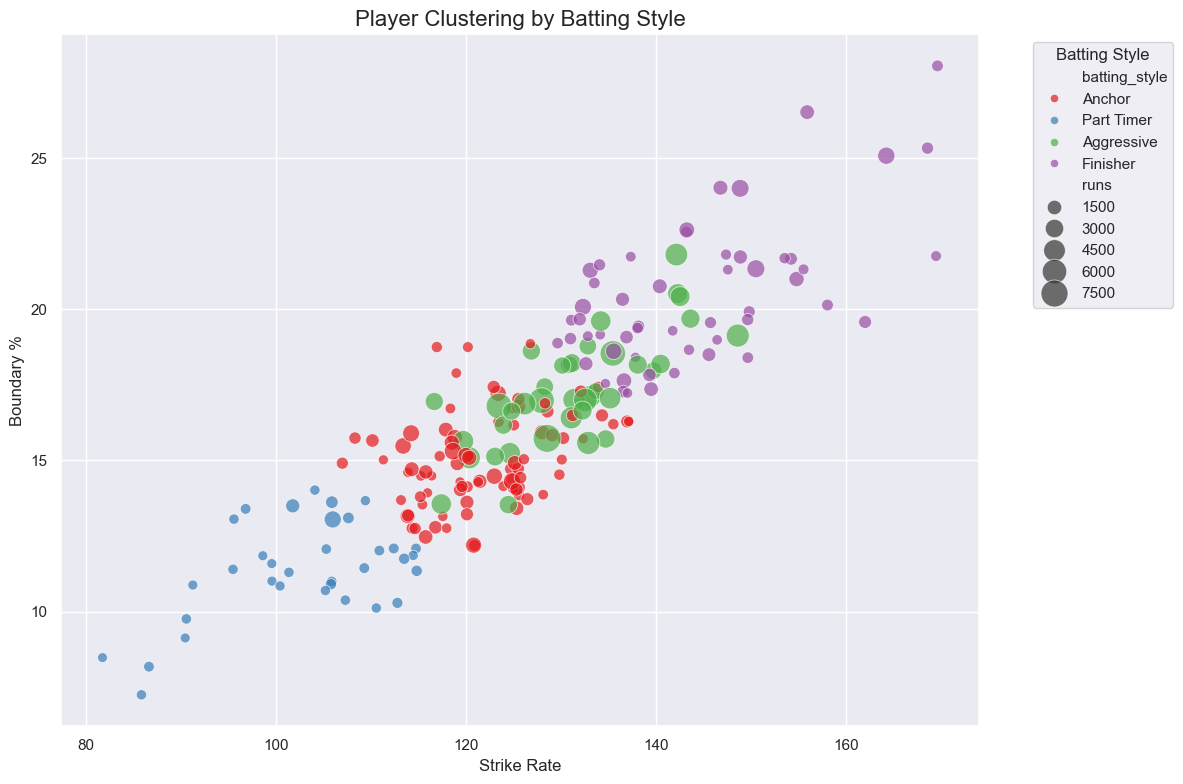


Top players per cluster:
Anchor: M Vijay, SPD Smith, SR Tendulkar
Part Timer: JH Kallis, SC Ganguly, HH Gibbs
Aggressive: V Kohli, S Dhawan, RG Sharma
Finisher: GJ Maxwell, V Sehwag, AD Russell


In [23]:
batter_stats = deliveries.groupby('batter').agg(
    runs=('batsman_runs', 'sum'),
    balls=('batsman_runs', 'count'),
    fours=('batsman_runs', lambda x: (x == 4).sum()),
    sixes=('batsman_runs', lambda x: (x == 6).sum())
).reset_index()

batter_stats['strike_rate'] = (batter_stats['runs'] / batter_stats['balls'] * 100).round(2)
batter_stats['boundary_pct'] = ((batter_stats['fours'] + batter_stats['sixes']) / batter_stats['balls'] * 100).round(2)
batter_stats = batter_stats[batter_stats['balls'] >= 200]

X_cluster = batter_stats[['strike_rate', 'boundary_pct', 'runs']].copy()
X_scaled = (X_cluster - X_cluster.mean()) / X_cluster.std()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
batter_stats['cluster'] = kmeans.fit_predict(X_scaled)

cluster_labels = {0: 'Anchor', 1: 'Aggressive', 2: 'Finisher', 3: 'Part Timer'}
batter_stats['batting_style'] = batter_stats['cluster'].map(cluster_labels)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=batter_stats, x='strike_rate', y='boundary_pct',
                hue='batting_style', size='runs', sizes=(50, 400),
                palette='Set1', alpha=0.7)
plt.title('Player Clustering by Batting Style', fontsize=16)
plt.xlabel('Strike Rate')
plt.ylabel('Boundary %')
plt.legend(title='Batting Style', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

print("\nTop players per cluster:")
for style in batter_stats['batting_style'].unique():
    top = batter_stats[batter_stats['batting_style'] == style].sort_values('runs', ascending=False).head(3)['batter'].tolist()
    print(f"{style}: {', '.join(top)}")

In [24]:
print("=== ML & PREDICTIONS SUMMARY ===")
print(f"Match prediction model accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(f"\nRegression: Win Rate vs First Ball Six Rate")
print(f"R² value: {r_value**2:.4f} — {'Strong' if r_value**2 > 0.5 else 'Weak'} relationship")
print(f"P-value: {p_value:.4f} — {'Statistically significant' if p_value < 0.05 else 'Not statistically significant'}")
print(f"\nToss impact on match outcome:")
print(f"Toss winners win the match {toss_corr[1]:.1f}% of the time")
print(f"\nPlayer clusters identified: {batter_stats['batting_style'].nunique()}")
print(f"Players clustered: {len(batter_stats)}")

=== ML & PREDICTIONS SUMMARY ===
Match prediction model accuracy: 54.1%

Regression: Win Rate vs First Ball Six Rate
R² value: 0.0186 — Weak relationship
P-value: 0.7262 — Not statistically significant

Toss impact on match outcome:
Toss winners win the match 50.6% of the time

Player clusters identified: 4
Players clustered: 210
